In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

### Calculate the average value of the data for each minute for 76 events (for BTC only)

In [3]:
path = "by_coin_panels/BTC_panels"

files = {
    "spread": f"{path}/panel_BTC_spread.csv",
    "e_spread": f"{path}/panel_BTC_avg_e_spread.csv",
    "depth": f"{path}/panel_BTC_depth.csv",
    "price": f"{path}/panel_BTC_avg_trade_price.csv",
    "volume": f"{path}/panel_BTC_volume.csv",
    "n_trades": f"{path}/panel_BTC_n_trades.csv",
}

# Define the time window and columns to average
time_window = 600  # ±600 minutes
columns_to_average = range(1, 77)  # The 2nd to the 77th column (Python index starts at 0)

# Initialize a dictionary to store the averaged data
averaged_data = {}

# Read each file and calculate the average value
for key, _file_ in files.items():
    df = pd.read_csv(_file_)
    
    zero_point_index = df[df['time'] == 0].index[0]   # Locate the 0th minute point
    df_window = df.iloc[zero_point_index - time_window : zero_point_index + time_window + 1]   # Extract the data within the time window
    
    averaged_data[key] = df_window.iloc[:, columns_to_average].mean(axis=1).values   # Calculate the average value of the data for each minute for 76 events

# Initialize the time axis
time_axis = df_window['time'].values

### Exploratory Visulization ######

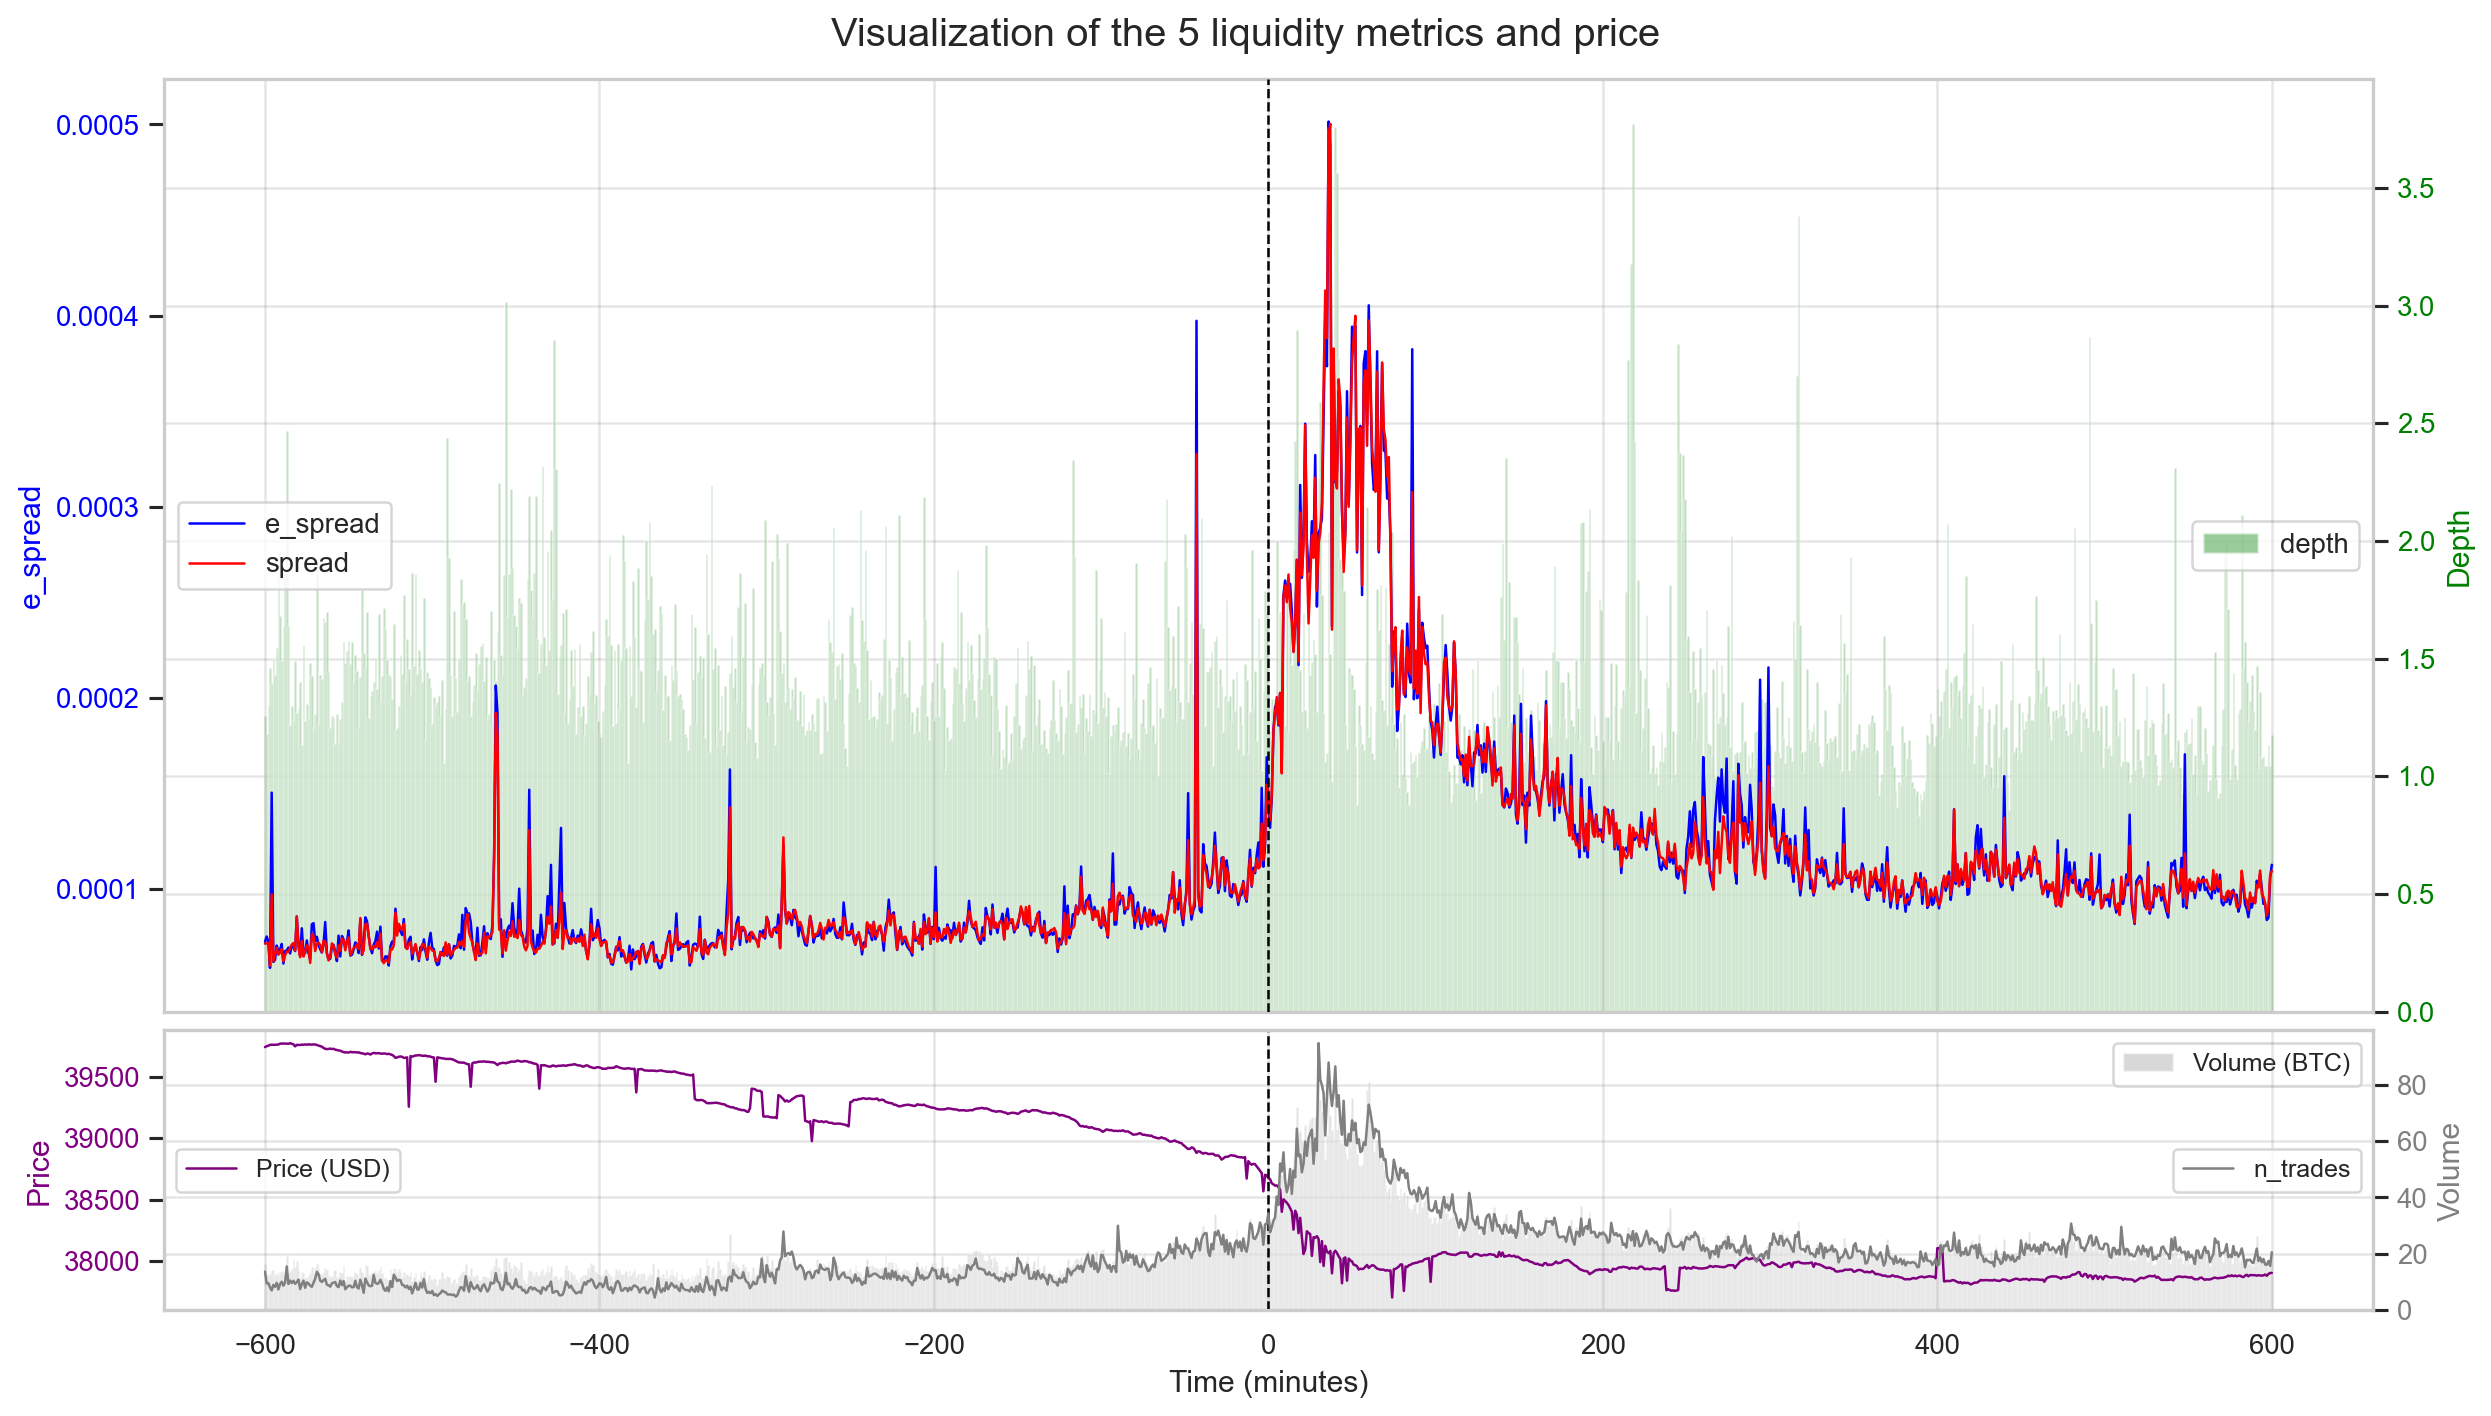

In [4]:
# Create a figure
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=180)

###### Mainplot ######
# e_spread & spread line plot (main axis)
ax1.plot(time_axis, averaged_data["e_spread"], label="e_spread", color="blue", linestyle="-", linewidth=1)
ax1.plot(time_axis, averaged_data["spread"], label="spread", color="red", linestyle="-", linewidth=1)
ax1.set_xlabel("") # hide the x-axis label
ax1.tick_params(axis="x", labelbottom=False) # hide the x-axis ticks
ax1.set_ylabel("e_spread", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.legend(loc="center left")

# depth bar plot (sub axis)
ax1_2 = ax1.twinx()
ax1_2.bar(time_axis, averaged_data["depth"], label="depth", color="green", alpha=0.4, width=1)
ax1_2.set_ylabel("Depth", color="green")
ax1_2.tick_params(axis="y", labelcolor="green")
ax1_2.legend(loc="center right")

# Add a black dashed line at the 0th minute point
ax1.axvline(x=0, color="black", linestyle="--", linewidth=1, zorder=10)

# Adjust the order of drawing axes
ax1.set_zorder(2)  # Set the zorder of ax1 higher
ax1_2.set_zorder(1)  # Set the zorder of ax1_2 lower
ax1.patch.set_visible(False)  # Avoid covering the background

# Add horizontal grid lines to the main plot
ax1.grid(True, axis='y', alpha=0.0, color='gray')  # Remove the horizontal grid lines of the main plot
ax1.grid(True, axis='x', alpha=0.2, color='gray')
ax1_2.grid(True, axis='y', alpha=0.2, color='gray')  # 移除主图的水平网格线
ax1_2.grid(True, axis='x', alpha=0.0, color='gray')


###### Subplot ######
ax2 = ax1.inset_axes([0, -0.32, 1, 0.3])  # adjust position and size [x0, y0, width, height]
ax2.set_facecolor("white")  # Set the background of ax2 to white

# Add the price line plot (main axis)
ax2.plot(time_axis, averaged_data["price"], label="Price (USD)", color="purple", linestyle="-", linewidth=1)
ax2.set_ylabel("Price", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")

# Add the volume bar plot (sub axis)
ax2_2 = ax2.twinx()
ax2_2.bar(time_axis, averaged_data["volume"], label="Volume (BTC)", color="gray", alpha=0.3, width=1)
ax2_2.set_ylabel("Volume", color="gray")
ax2_2.tick_params(axis="y", labelcolor="gray")

# Add the n_trades line plot (sub axis)
ax2_3 = ax2.twinx()
ax2_3.plot(time_axis, averaged_data["n_trades"], label="n_trades", color="gray", linestyle="-", linewidth=1)
ax2_3.set_yticks([])  # hide the y-axis ticks
ax2_3.set_ylabel('')  # hide the y-axis label

# Set the y-axis of volume
ax2_2.set_ylabel("Volume", color="gray")
ax2_2.tick_params(axis="y", labelcolor="gray")

# Add a black dashed line at the 0th minute point
ax2.axvline(x=0, color="black", linestyle="--", linewidth=1, zorder=10)

# Add the x-axis grid lines
ax2.grid(True, axis='x', alpha=0.3, color='gray', linestyle='--')
ax2.grid(False, axis='y')  # hide the y-axis grid lines

# Add the legend
ax2.legend(loc="center left", fontsize=10)
ax2_2.legend(loc="upper right", fontsize=10)
ax2_3.legend(loc="center right", fontsize=10)

# Set the x-axis label
ax2.set_xlabel("Time (minutes)")

# Show the line plot above the bar plot
ax2.set_zorder(2) 
ax2_2.set_zorder(1)
ax2.patch.set_visible(False)
ax2.grid(True, axis='y', alpha=0.0, color='gray', linestyle='-') # Remove the horizontal grid lines of the main plot
ax2.grid(True, axis='x', alpha=0.2, color='gray', linestyle='-')
ax2_2.grid(True, axis='y', alpha=0.2, color='gray', linestyle='-')  # Remove the horizontal grid lines of the main plot
ax2_2.grid(True, axis='x', alpha=0.0, color='gray', linestyle='-')

# Adjust the layout and title
plt.tight_layout()
plt.suptitle("Visualization of the 5 liquidity metrics and price", y=1.02, fontsize=16)
plt.show()

In the above figure, apparently the lines of `spread` and `e_spread` are highly overlapping, as are `volume` and `n_trades`.     
Therefore, in our formal presentation, we have retained only `e_spread` and `volume` (as shown below) in order to optimize the readability of the chart.   
In addition, in the ±600 minute window, the `depth` doesn't show explanatory up or down movement, which is because it's a long-term indicator. Therefore, we remove it in this part of future analysis.

_(The same code as above no longer has explanations.)_

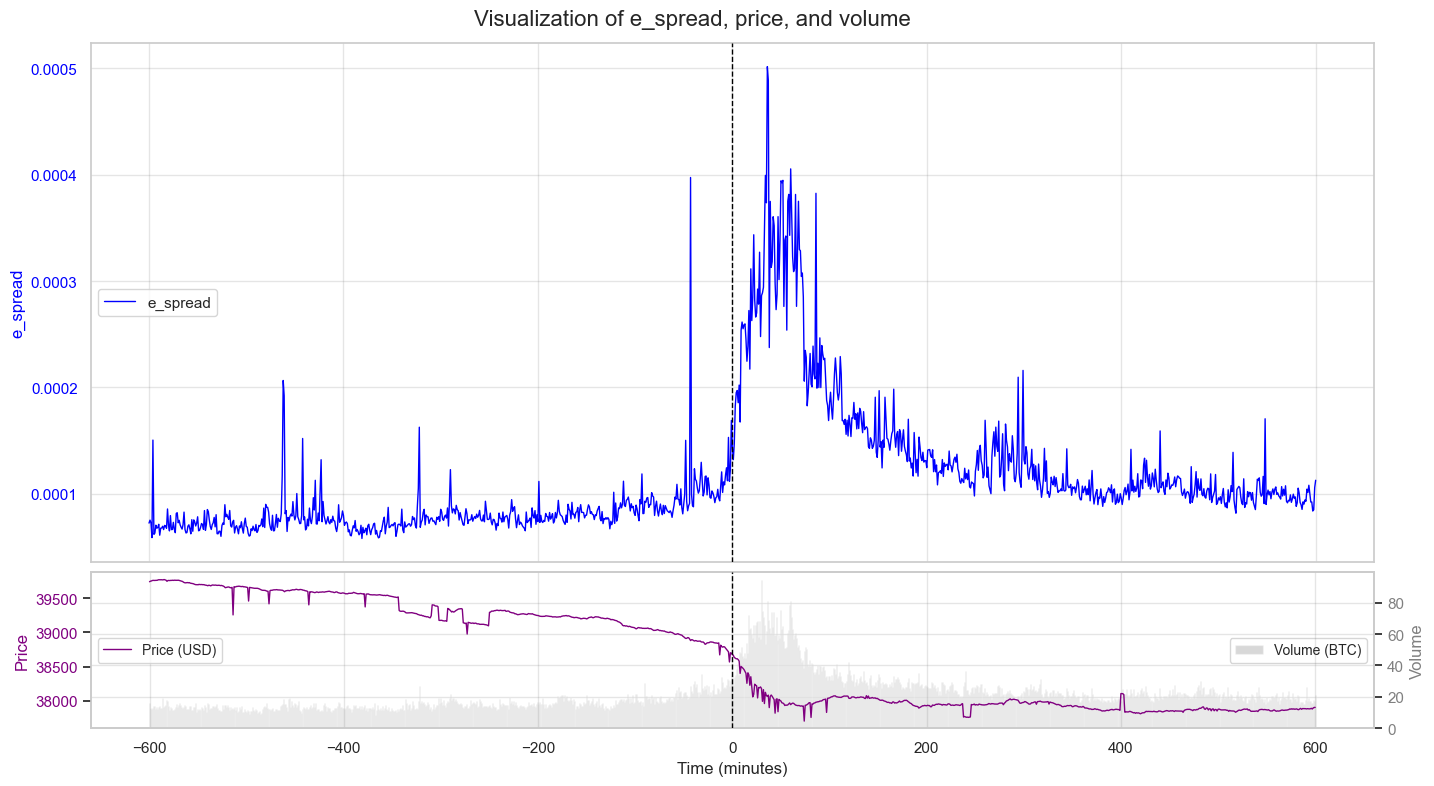

In [5]:
# Unfold the function to see details
def plot_crypto_metrics(time_axis, averaged_data, coin="BTC", title="Visualization of e_spread, price, and volume"):
    """
    Plots cryptocurrency metrics including e_spread, depth, price, and volume.

    Parameters:
    - time_axis: array-like, the time axis for the plot (e.g., minutes).
    - averaged_data: dict, contains the following keys with corresponding data arrays:
        - "e_spread": Effective spread data.
        - "depth": Market depth data.
        - "price": Cryptocurrency price data.
        - "volume": Trading volume data.
    - title: str, the title of the plot (default is "Visualization of e_spread, depth, price, and volume").
    """
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Plot e_spread
    ax1.plot(time_axis, averaged_data["e_spread"], label="e_spread", color="blue", linestyle="-", linewidth=1)
    
    # Add vertical line at x=0
    ax1.axvline(x=0, color="black", linestyle="--", linewidth=1, zorder=10)
    ax1.tick_params(axis="x", labelbottom=False)
    ax1.set_ylabel("e_spread", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.legend(loc="center left")
    
    # Adjust z-order and grid
    ax1.set_zorder(2)
    ax1_2.set_zorder(1)
    ax1.patch.set_visible(False)
    ax1.grid(True, axis='y', alpha=0.2, color='gray')
    ax1.grid(True, axis='x', alpha=0.2, color='gray')

    # Create inset axes for price and volume
    ax2 = ax1.inset_axes([0, -0.32, 1, 0.3])
    ax2.set_facecolor("white")
    ax2.plot(time_axis, averaged_data["price"], label="Price (USD)", color="purple", linestyle="-", linewidth=1, zorder=3)
    ax2.set_ylabel("Price", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    
    # Add volume bars
    ax2_2 = ax2.twinx()
    ax2_2.bar(time_axis, averaged_data["volume"], label=f"Volume ({coin})", color="gray", alpha=0.3, width=1, zorder=1)
    ax2_2.set_ylabel("Volume", color="gray")
    ax2_2.tick_params(axis="y", labelcolor="gray")
    
    # Add vertical line at x=0
    ax2.axvline(x=0, color="black", linestyle="--", linewidth=1, zorder=10)
    
    # Adjust grid, labels, and legends
    ax2.grid(True, axis='x', alpha=0.3, color='gray', linestyle='--')
    ax2.grid(False, axis='y')
    ax2.legend(loc="center left", fontsize=10)
    ax2_2.legend(loc="center right", fontsize=10)
    ax2.set_xlabel("Time (minutes)")
    
    ax2.set_zorder(2)
    ax2_2.set_zorder(1)
    ax2.patch.set_visible(False)
    ax2.grid(True, axis='y', alpha=0.0, color='gray', linestyle='-')
    ax2.grid(True, axis='x', alpha=0.2, color='gray', linestyle='-')
    ax2_2.grid(True, axis='y', alpha=0.2, color='gray', linestyle='-')
    ax2_2.grid(True, axis='x', alpha=0.0, color='gray', linestyle='-')

    # Add title and layout adjustments
    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.show()
    
plot_crypto_metrics(time_axis, averaged_data)


### By-event-type Plots

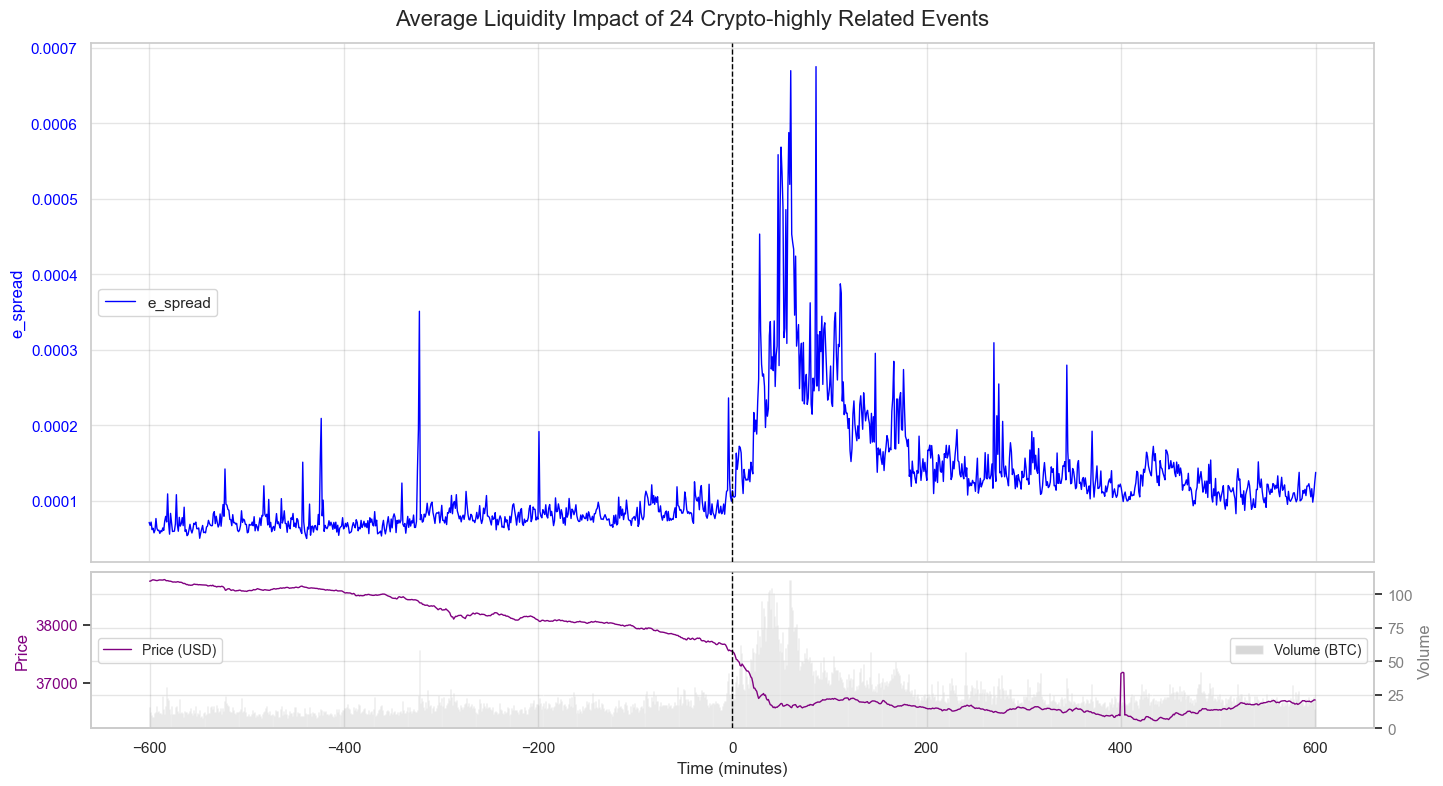

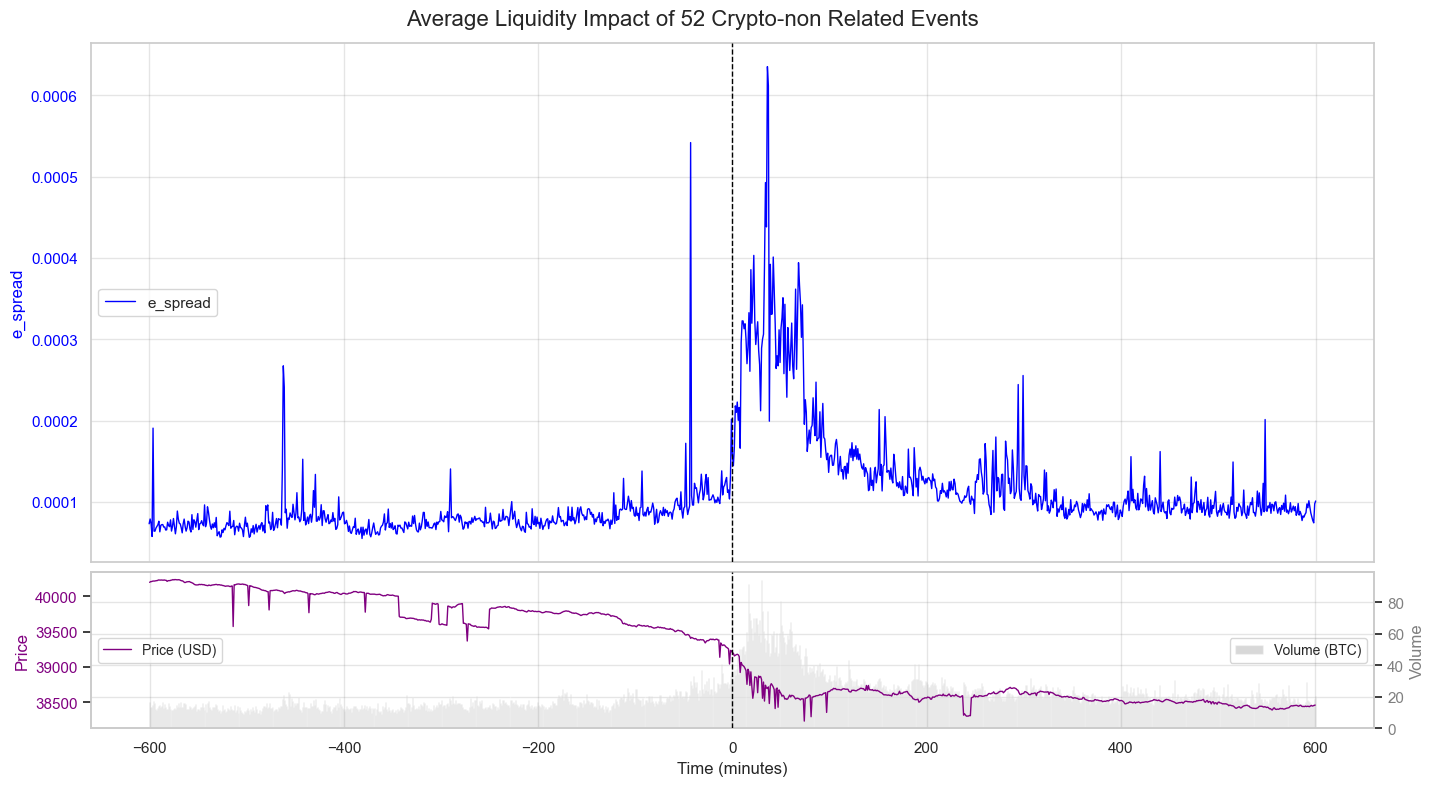

In [9]:
event_data = pd.read_csv("event_filter(incl_ob_hour_&_types).csv")            # load the event type data
binary_types = event_data.set_index("event_index")["Binary Type"].to_dict()   # we only split the data by the binary type

averaged_data_type_0 = {}  # type_0 indicates the NON-crypto news
averaged_data_type_1 = {}  # type_1 indicates the crypto news

for key, _file_ in files.items():
    df = pd.read_csv(_file_)
    
    zero_point_index = df[df['time'] == 0].index[0]  # 找到时间为 0 的索引
    df_window = df.iloc[zero_point_index - time_window : zero_point_index + time_window + 1]  # 提取时间窗口内的数据
    
    # 筛选 Binary Type 0 和 Binary Type 1 的列
    type_0_columns = [i for i, col in enumerate(df.columns[1:], start=1) if binary_types[f"event{i}"] == 0]
    type_1_columns = [i for i, col in enumerate(df.columns[1:], start=1) if binary_types[f"event{i}"] == 1]
    
    # 计算平均值
    averaged_data_type_0[key] = df_window.iloc[:, type_0_columns].mean(axis=1).values
    averaged_data_type_1[key] = df_window.iloc[:, type_1_columns].mean(axis=1).values

plot_crypto_metrics(time_axis, averaged_data_type_0, title="Average Liquidity Impact of 24 Crypto-highly Related Events")
plot_crypto_metrics(time_axis, averaged_data_type_1, title="Average Liquidity Impact of 52 Crypto-non Related Events")

### By-coin Plots

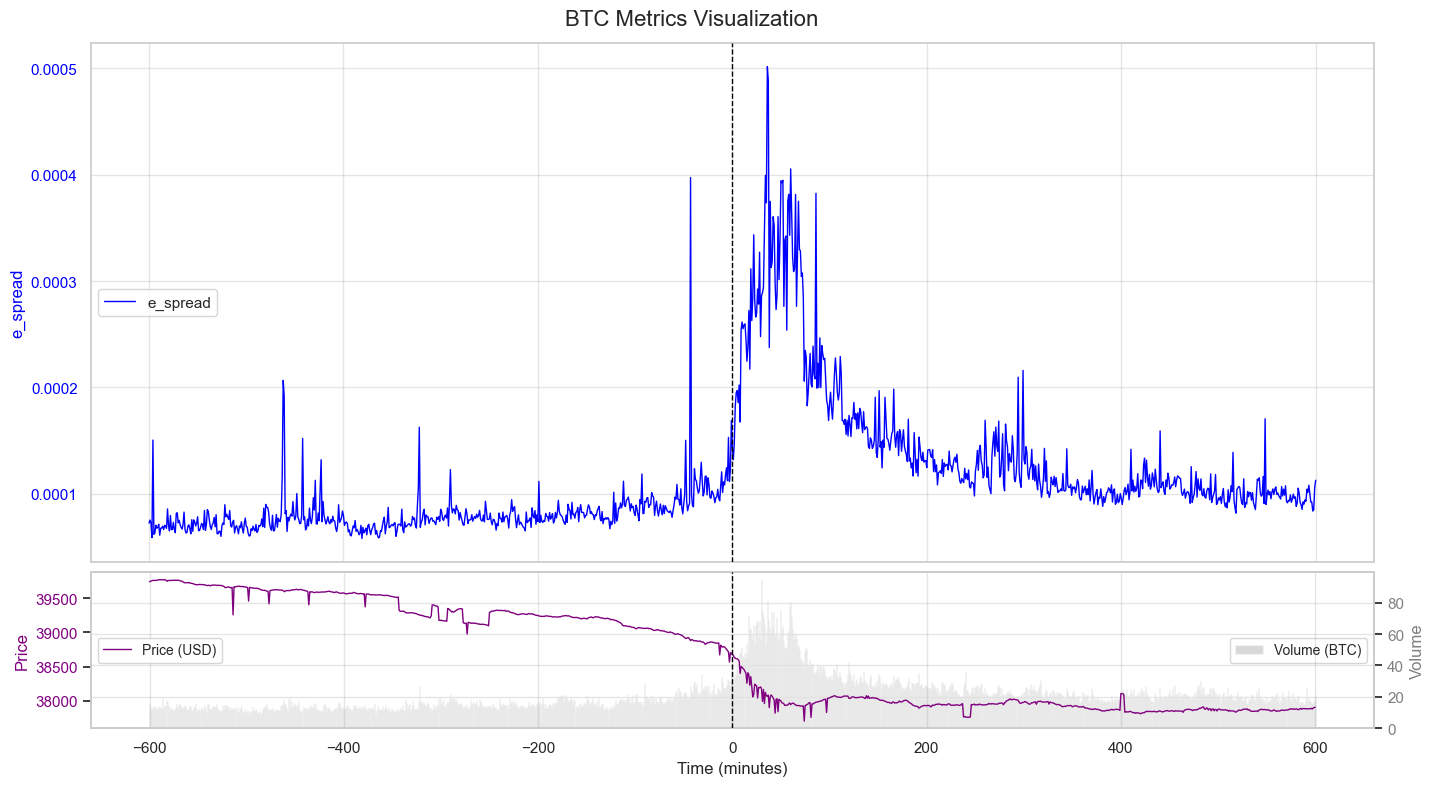

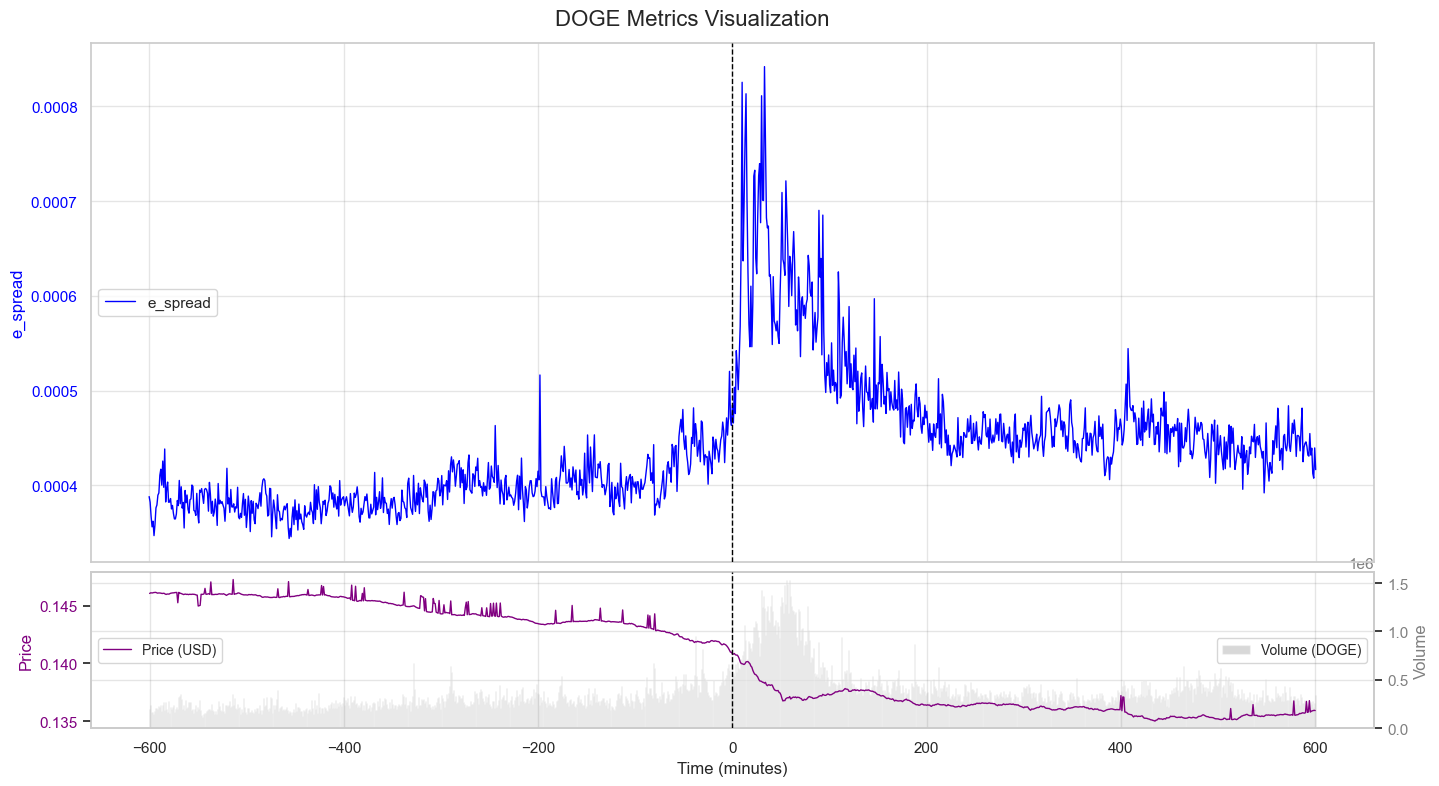

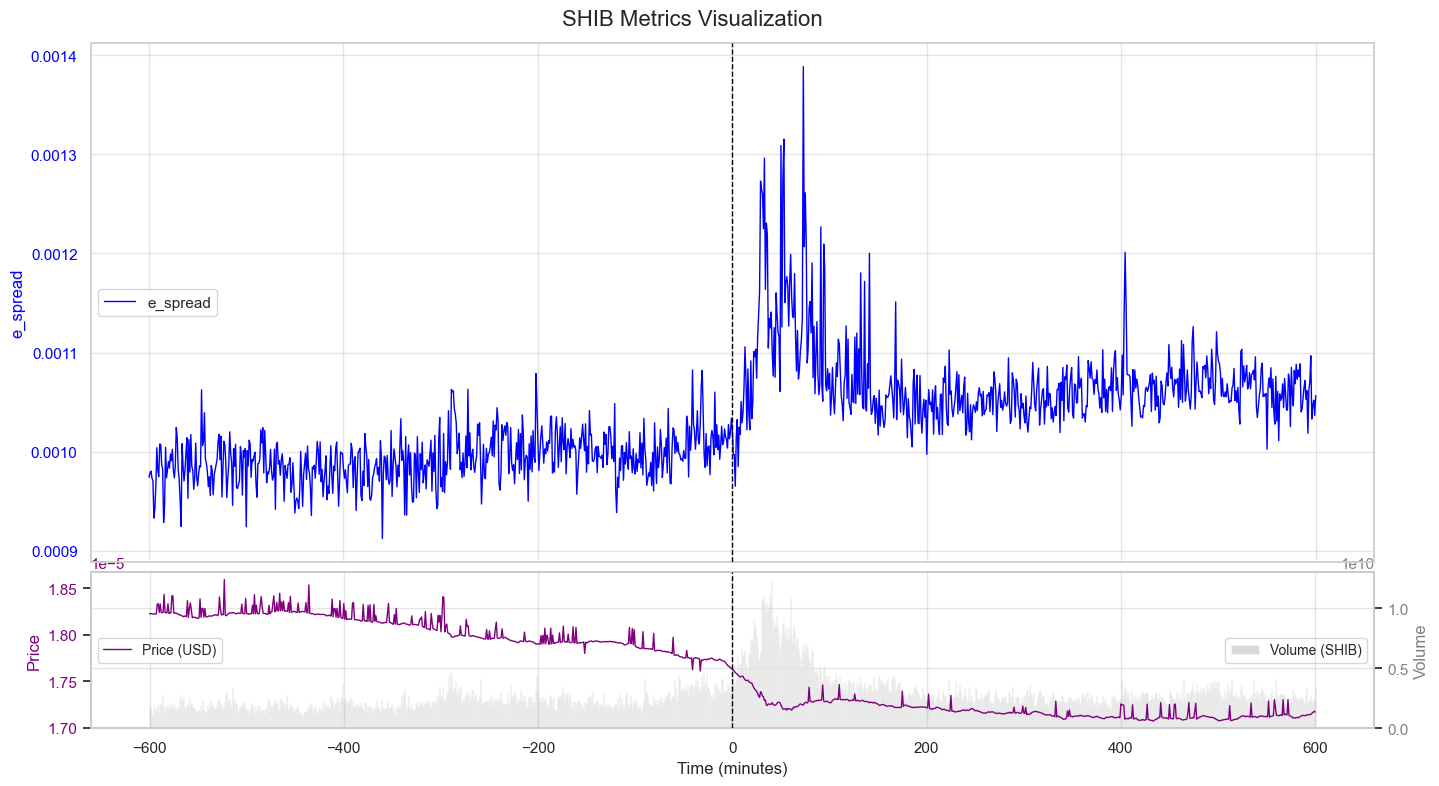

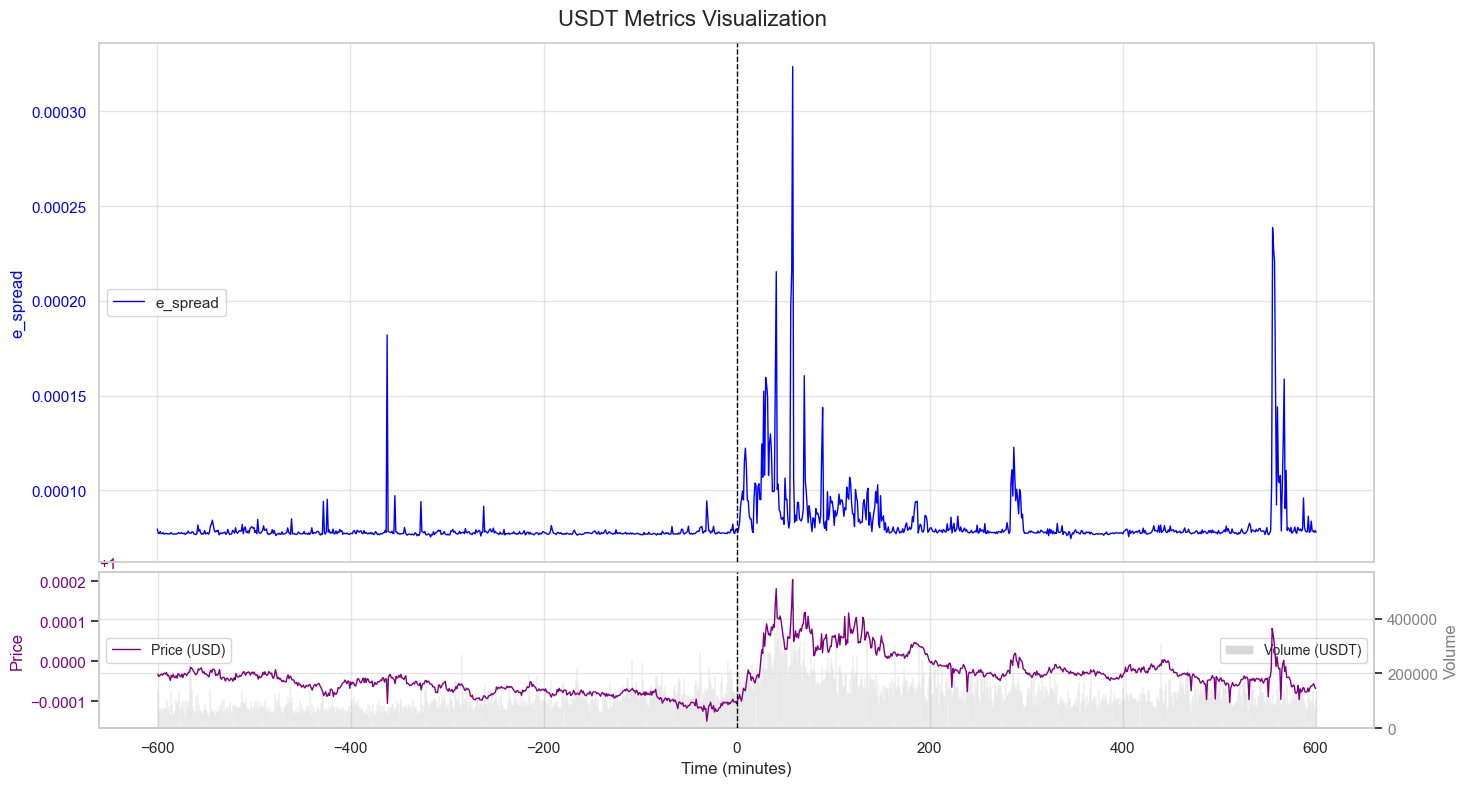

In [29]:
# 定义加密货币文件夹路径
base_path = "by_coin_panels"
coins = ["BTC", "DOGE", "SHIB", "USDT"]

# 定义文件名模板

def calculate_average_metrics(coin):
    coin_files = {
    "spread": f"{base_path}/{coin}_panels/panel_{coin}_spread.csv",
    "e_spread": f"{base_path}/{coin}_panels/panel_{coin}_avg_e_spread.csv",
    "depth": f"{base_path}/{coin}_panels/panel_{coin}_depth.csv",
    "price": f"{base_path}/{coin}_panels/panel_{coin}_avg_trade_price.csv",
    "volume": f"{base_path}/{coin}_panels/panel_{coin}_volume.csv",
    "n_trades": f"{base_path}/{coin}_panels/panel_{coin}_n_trades.csv",
    }
    
    # Initialize a dictionary to store the averaged data
    averaged_data = {}
    
    # Read each file and calculate the average value
    for key, _file_ in coin_files.items():
        df = pd.read_csv(_file_)
        
        zero_point_index = df[df['time'] == 0].index[0]   # Locate the 0th minute point
        df_window = df.iloc[zero_point_index - time_window : zero_point_index + time_window + 1]   # Extract the data within the time window
        
        max_columns = df_window.shape[1]  # because the coins other than BTC have fewer events, we need to adjust the columns range
        valid_columns = range(1, min(max_columns, len(columns_to_average) + 1))  # dynamically adjust the column range
        averaged_data[key] = df_window.iloc[:, valid_columns].mean(axis=1).values

    # Initialize the time axis
    time_axis = df_window['time'].values
    
    return averaged_data, time_axis

# 遍历每个加密货币文件夹
time_window = 600  # 时间窗口大小（±600分钟）
for coin in coins:
    # 获取当前币种的时间轴和平均值数据
    averaged_data, time_axis = calculate_average_metrics(coin)
    
    # 调用绘图函数，传入当前币种的数据
    plot_crypto_metrics(time_axis, averaged_data, coin, f"{coin} Metrics Visualization")



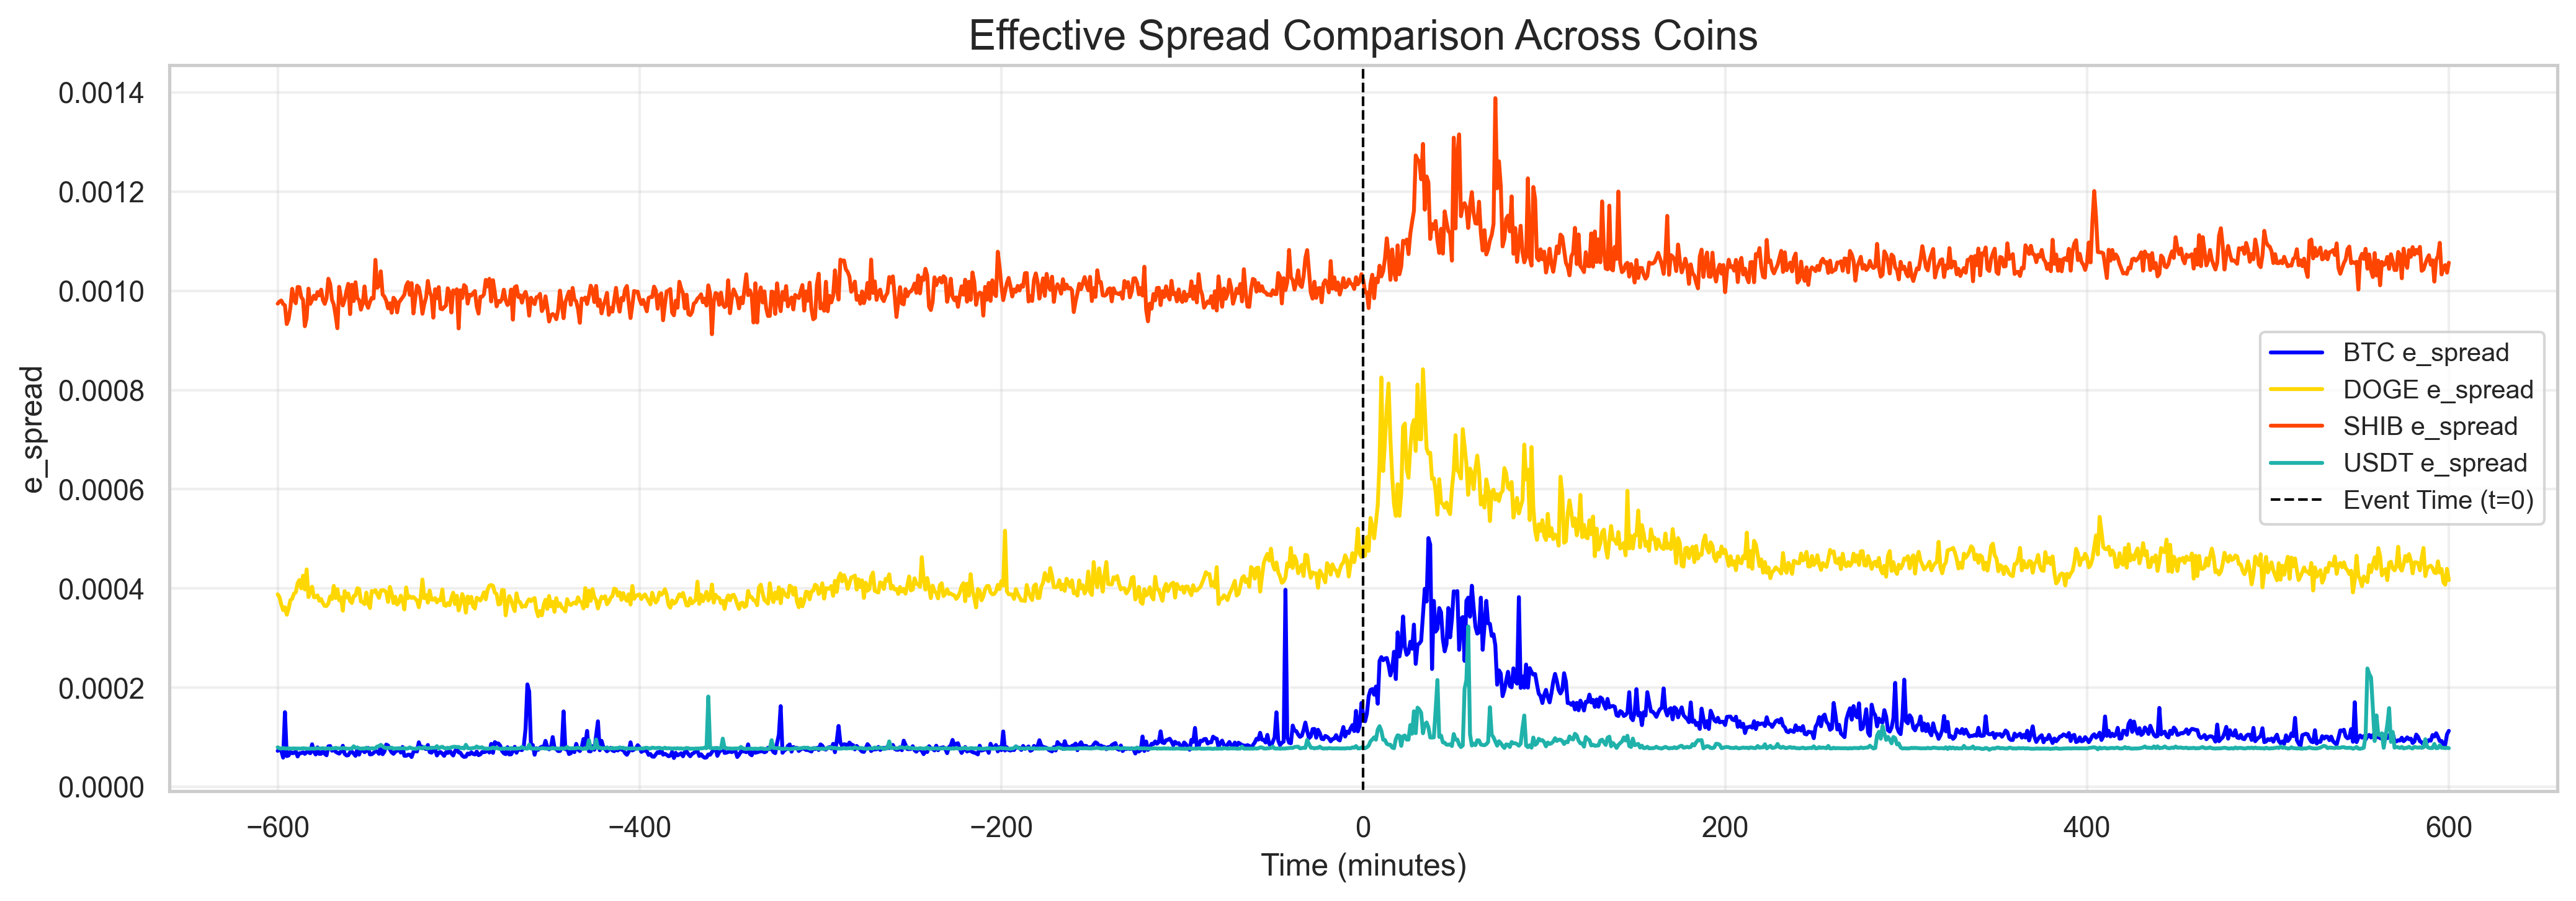

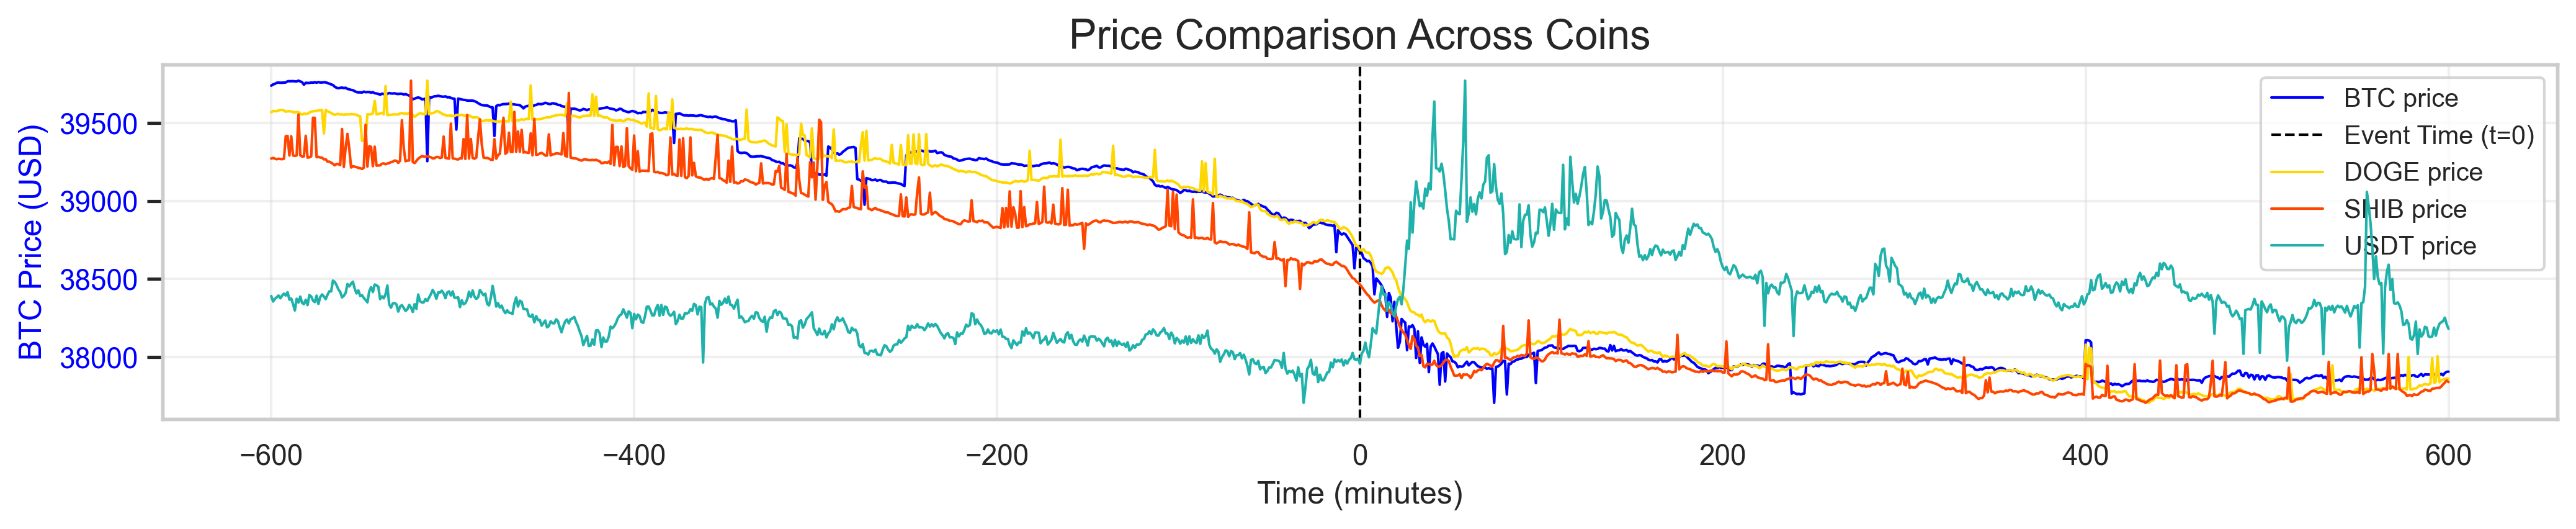

In [59]:
colors = {
    "BTC": "blue",
    "DOGE": "gold",
    "SHIB": "orangered",
    "USDT": "lightseagreen"
}

all_averaged_data = {}
all_time_axis = {}

for coin in coins:
    averaged_data, time_axis = calculate_average_metrics(coin)
    all_averaged_data[coin] = averaged_data
    all_time_axis[coin] = time_axis

# Plot by-coin e_spread
plt.figure(figsize=(14, 5), dpi=300)
for coin in coins:
    plt.plot(all_time_axis[coin], all_averaged_data[coin]["e_spread"], label=f"{coin} e_spread", color=colors[coin])

plt.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Event Time (t=0)")
plt.title("Effective Spread Comparison Across Coins", fontsize=16)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("e_spread", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot by-coin price
fig, ax1 = plt.subplots(figsize=(14, 3), dpi=300)

# Main axis: plot BTC's price
ax1.plot(all_time_axis["BTC"], all_averaged_data["BTC"]["price"], label="BTC price", color=colors["BTC"], linewidth=1)
ax1.set_xlabel("Time (minutes)", fontsize=12)
ax1.set_ylabel("BTC Price (USD)", fontsize=12, color=colors["BTC"])
ax1.tick_params(axis="y", labelcolor=colors["BTC"])
ax1.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Event Time (t=0)")
ax1.grid(alpha=0.3)

# Sub axis: plot other coins' price
ax2 = ax1.twinx()
ax2.plot(all_time_axis["DOGE"], all_averaged_data["DOGE"]["price"], label="DOGE price", color=colors["DOGE"], linewidth=1)
ax2.tick_params(axis="y", colors="none")  # hide the sub axis's ticks
ax2.set_yticks([])  # hide the sub axis's labels
ax2.grid(alpha=0.0)

# Sub axis: plot SHIB's price    
ax2_1 = ax1.twinx()
ax2_1.plot(all_time_axis["SHIB"], all_averaged_data["SHIB"]["price"], label="SHIB price", color=colors["SHIB"], linewidth=1)
ax2_1.tick_params(axis="y", colors="none")  # hide the sub axis's ticks
ax2_1.set_yticks([])  # hide the sub axis's labels
ax2_1.grid(alpha=0.0)

# 第三个副轴：绘制 USDT 的 price
ax2_2 = ax1.twinx()
ax2_2.plot(all_time_axis["USDT"], all_averaged_data["USDT"]["price"], label="USDT price", color=colors["USDT"], linewidth=1)
ax2_2.tick_params(axis="y", colors="none")  # hide the sub axis's ticks
ax2_2.set_yticks([])  # hide the sub axis's labels
ax2_2.grid(alpha=0.0)

# Add legend      
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax2_1.get_legend_handles_labels()
lines_4, labels_4 = ax2_2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2 + lines_3 + lines_4,
    labels_1 + labels_2 + labels_3 + labels_4,
    loc="upper right",
    fontsize=10,
)

# Set title  
plt.title("Price Comparison Across Coins", fontsize=16)
plt.tight_layout()
plt.show()